In [8]:
# Time series / stats imports
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# plotting defaults
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)


In [9]:
#creating path for data import 
path = r'/Users/thomaskimber/Desktop/Task 7'

In [10]:
# importing UFC data csv 
df = pd.read_csv(os.path.join(path,'ufc_data.csv' ), index_col = False)

In [11]:
# assume df is already loaded (ufc_data.csv)
# ensure date column exists and parseable
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# drop rows with invalid dates
df = df.dropna(subset=['date']).copy()

# remove any future / forecasted rows (today is 2025-09-10 in your environment)
cutoff = pd.to_datetime("2025-09-10")
df = df[df['date'] <= cutoff]

# --- Aggregate to monthly counts of fights ---
# create a column for month period
df['month'] = df['date'].dt.to_period('M')

# count fights per month
ts = df.groupby('month').size().rename('fights_count').to_frame()

# convert PeriodIndex to DatetimeIndex at month start for plotting / decomposition
ts.index = ts.index.to_timestamp()

# --- Optional subsetting ---
# If you want to restrict to a specific historical window, set these:
# start_date = '2010-01-01'
# end_date   = '2024-12-31'
# Otherwise leave as None to use full range
start_date = None
end_date = None

if start_date:
    ts = ts[ts.index >= pd.to_datetime(start_date)]
if end_date:
    ts = ts[ts.index <= pd.to_datetime(end_date)]

# Reset index advice (if you subset and need Date as index)
# ts = ts.reset_index().set_index('month')  # not needed here; ts is already indexed by timestamp

# Quick view
print("Time series range:", ts.index.min(), "to", ts.index.max())
print(ts.head())


Time series range: 1994-03-01 00:00:00 to 2021-03-01 00:00:00
            fights_count
month                   
1994-03-01            15
1994-09-01             6
1994-12-01             8
1995-04-01            10
1995-07-01             8


I aggregated the dataset to monthly counts (fights_count) to create a regular time series. I removed any rows with invalid or future dates (cutoff: 2025-09-10) to ensure no forecasted data is included. If I needed to focus on a specific historical window (for example, remove early noisy records or very recent incomplete months), I would set start_date and end_date before analysis.

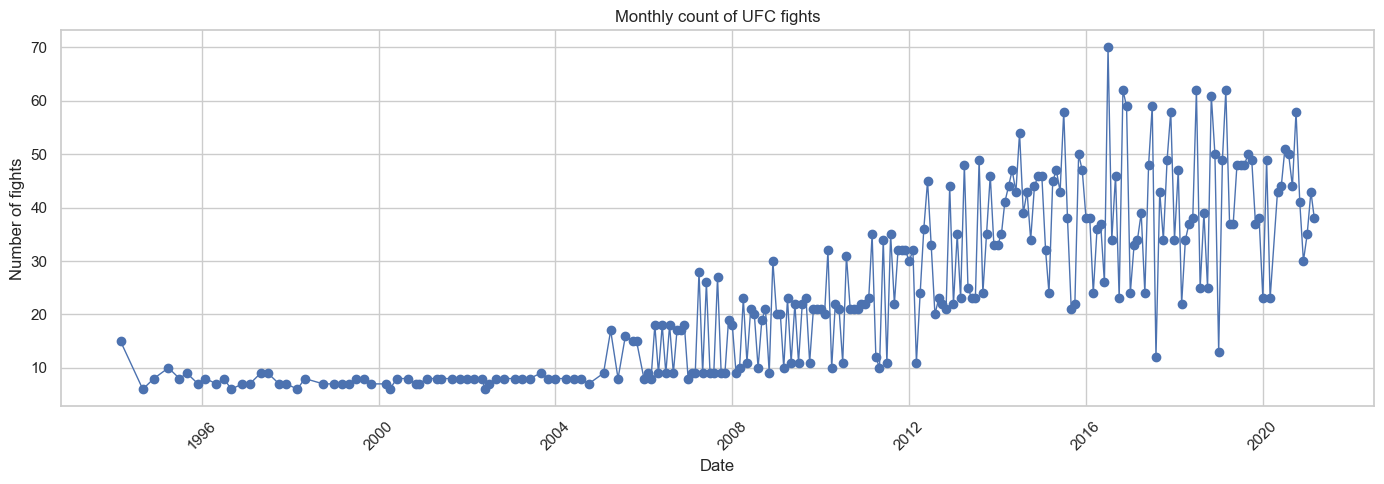

In [12]:
plt.figure(figsize=(14,5))
plt.plot(ts.index, ts['fights_count'], marker='o', linewidth=1)
plt.title('Monthly count of UFC fights')
plt.xlabel('Date')
plt.ylabel('Number of fights')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


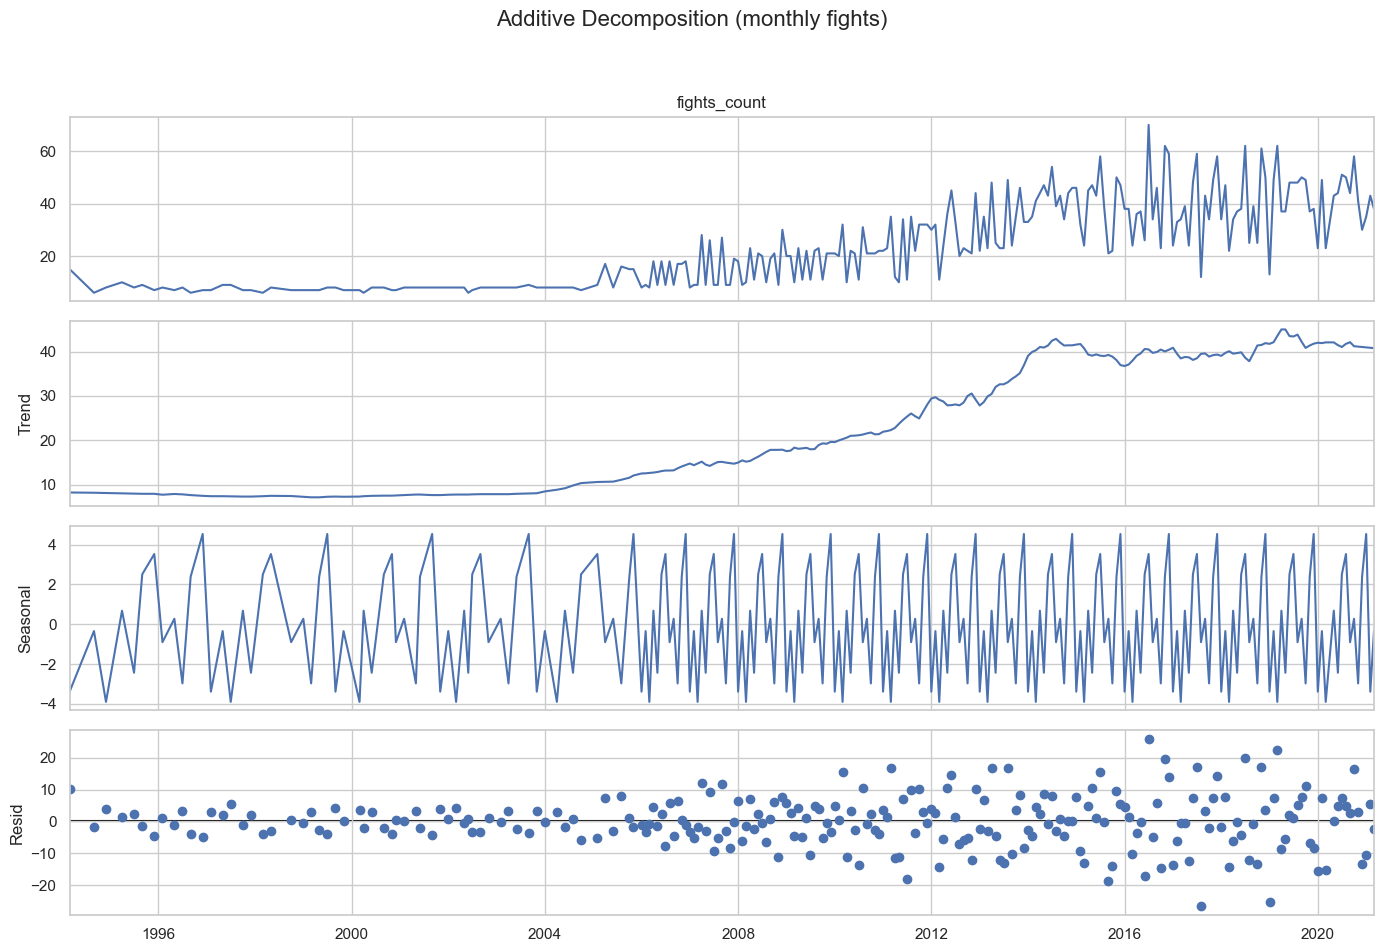

In [13]:
# seasonal_decompose requires a frequency; since we use monthly data, period=12
decomp = seasonal_decompose(ts['fights_count'], model='additive', period=12, extrapolate_trend='freq')

fig = decomp.plot()
fig.set_size_inches(14,10)
plt.suptitle('Additive Decomposition (monthly fights)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


It’s clear there are a few trends going on with this time series data. Firstly, with fight counts, we can see a steady growth until about 2012, where we start to see a larger gap between the high and lows of fight counts. This could mean they’re doing larger events with more fights on the card, and then larger gaps between those where, in the past, they may have done less larger events more often, which could explain the variances.

There’s a definite upwards trend until 2012, where it flattened out. This could mean two things: either they found a model and fight schedule that worked for them and stuck to it, or they’ve physically reached their maximum amount of fights they can have in a calendar year. It’s also interesting to note that UFC wasn’t affected by COVID and might have been one of the only sports that didn’t see a decrease in their schedule.

There’s definitely seasonality to the fight trends. What’s interesting is that in 2006, the gap between seasons shortened. Something must have happened to their business that increased their ability to put fights on more frequently. 

In [14]:
def run_adf_test(series, autolag='AIC'):
    result = adfuller(series.dropna(), autolag=autolag)
    output = {
        'adf_stat': result[0],
        'p_value': result[1],
        'used_lag': result[2],
        'n_obs': result[3],
        'crit_values': result[4],
        'icbest': result[5] if len(result) > 5 else None
    }
    return output

adf_res = run_adf_test(ts['fights_count'])
print("ADF statistic: {:.4f}".format(adf_res['adf_stat']))
print("p-value: {:.4f}".format(adf_res['p_value']))
print("Critical values:")
for k, v in adf_res['crit_values'].items():
    print(f"  {k}: {v:.4f}")


ADF statistic: -0.5817
p-value: 0.8751
Critical values:
  1%: -3.4591
  5%: -2.8742
  10%: -2.5735


Interpretation
Null hypothesis (H₀): The time series is non-stationary (it has a trend or seasonality).
Alternative hypothesis (H₁): The series is stationary.
The p-value (0.8751) is much higher than the 0.05 threshold.
The ADF statistic (-0.58) is not more negative than any of the critical values (−2.57, −2.87, −3.45).
Therefore, we fail to reject the null hypothesis.
This indicates that the series is non-stationary and likely contains a trend or seasonal structure.

In [20]:
ts['fights_count_diff1'] = ts['fights_count'] - ts['fights_count'].shift(1)
ts_diff1 = ts['fights_count_diff1'].dropna()

# ADF test again
adf_result_diff1 = adfuller(ts_diff1)
print("ADF statistic after first differencing:", adf_result_diff1[0])
print("p-value:", adf_result_diff1[1])


ADF statistic after first differencing: -9.202764719567991
p-value: 1.981563085056342e-15


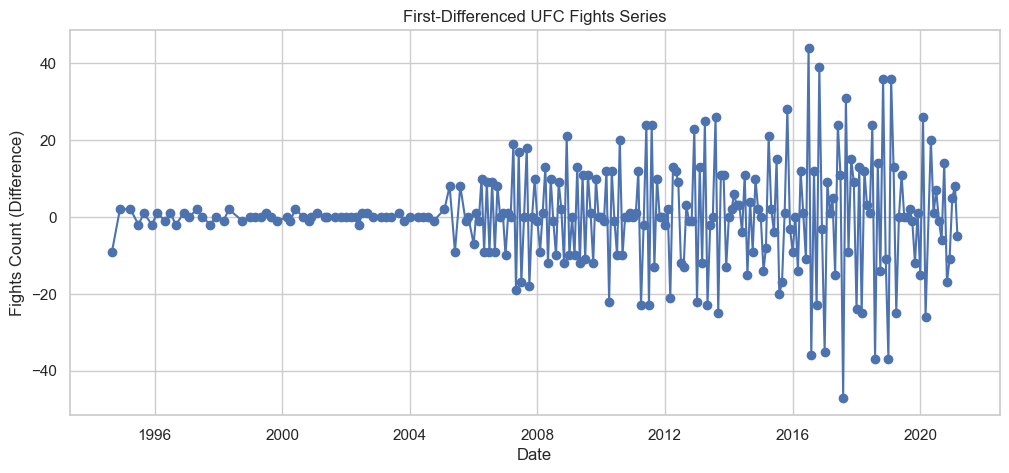

<Figure size 1200x400 with 0 Axes>

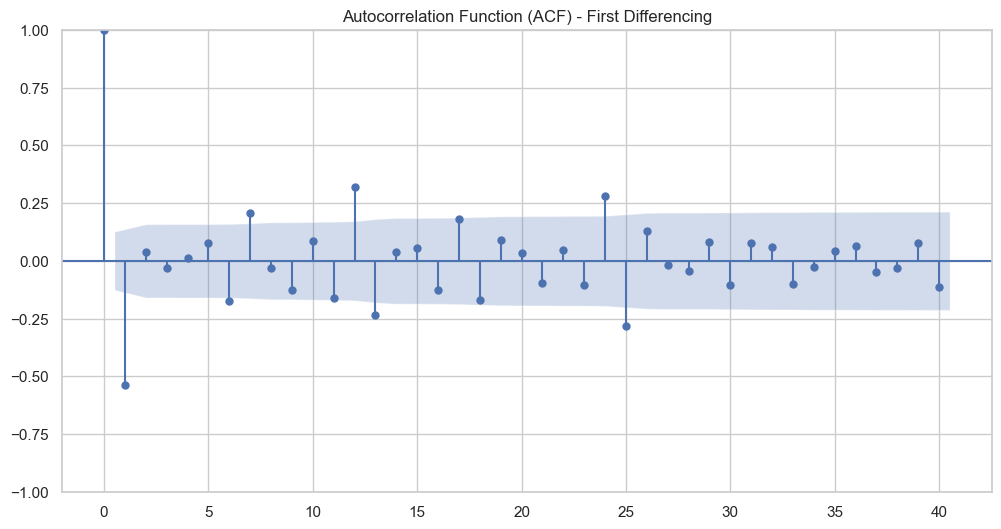

<Figure size 1200x400 with 0 Axes>

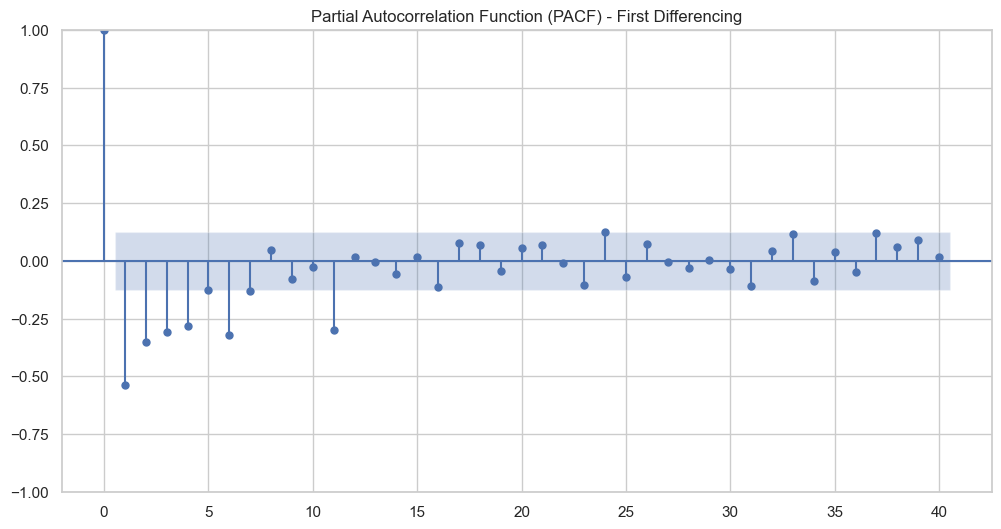

In [21]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ===========================
# 1) Plot first-differenced series
# ===========================
plt.figure(figsize=(12,5))
plt.plot(ts_diff1.index, ts_diff1, marker='o', linestyle='-')
plt.title("First-Differenced UFC Fights Series")
plt.xlabel("Date")
plt.ylabel("Fights Count (Difference)")
plt.grid(True)
plt.show()

# ===========================
# 2) Plot Autocorrelation Function (ACF)
# ===========================
plt.figure(figsize=(12,4))
plot_acf(ts_diff1, lags=40)
plt.title("Autocorrelation Function (ACF) - First Differencing")
plt.show()

# ===========================
# 3) Plot Partial Autocorrelation Function (PACF)
# ===========================
plt.figure(figsize=(12,4))
plot_pacf(ts_diff1, lags=40)
plt.title("Partial Autocorrelation Function (PACF) - First Differencing")
plt.show()
